<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/OR_Gate_using_parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Parameters
w1 = -0.251, w2 = 0.901, b = 0.000

Training Single Neuron (OR Gate)...
Iteration    0: Loss = 0.4235
Iteration 1000: Loss = 0.2693
Iteration 2000: Loss = 0.2290

Training Complete!
Final Weights: w1=1.818, w2=2.053
Final Bias: b=-0.531

Predictions (OR Gate):
Input: [0, 0] -> Pred≈0.370 (Class 0)
Input: [0, 1] -> Pred≈0.821 (Class 1)
Input: [1, 0] -> Pred≈0.784 (Class 1)
Input: [1, 1] -> Pred≈0.966 (Class 1)


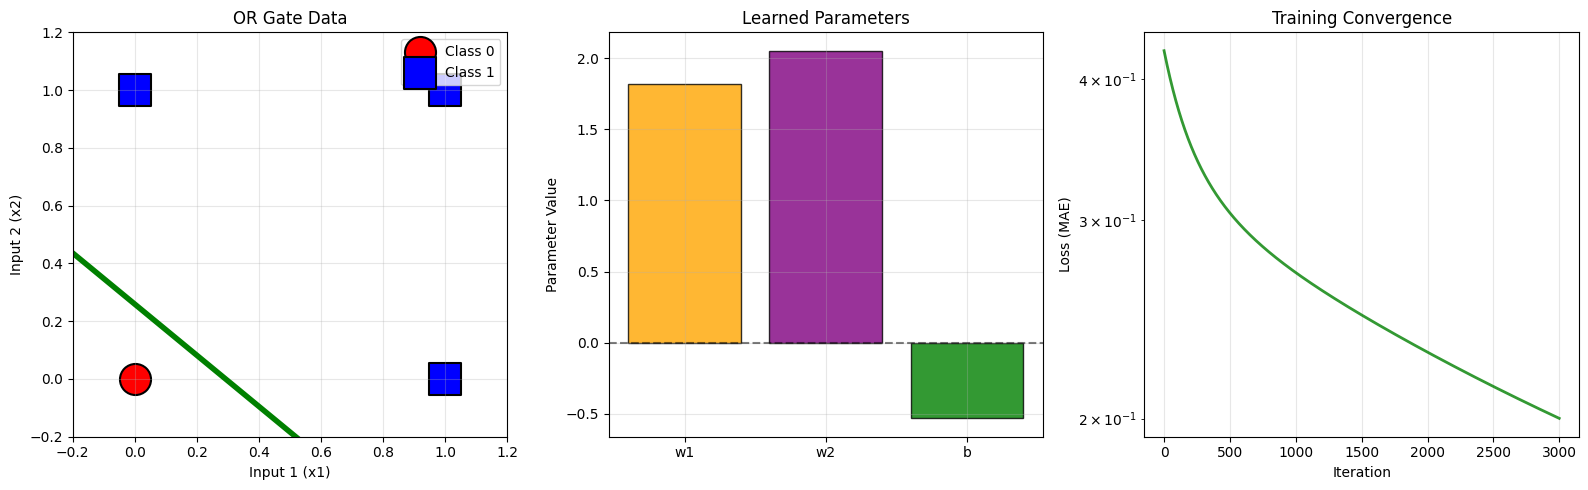


DECISION BOUNDARY VERIFICATION:
Equation: 1.818*x1 + 2.053*x2 + -0.531 = 0
Solved for x2: x2 = (--0.531 - 1.818*x1) / 2.053

Point positions relative to boundary:
Input [0, 0]: z = -0.531 -> Below (Class 0 region)
Input [0, 1]: z = 1.522 -> Above (Class 1 region)
Input [1, 0]: z = 1.287 -> Above (Class 1 region)
Input [1, 1]: z = 3.339 -> Above (Class 1 region)


In [1]:
#OR Gate using parameters
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# Inputs for OR gate as 1D arrays
x1 = np.array([0, 0, 1, 1])   # first input
x2 = np.array([0, 1, 0, 1])   # second input

# Stack for convenience only where needed (for gradients, etc.)
# Shape: (4, 2)
X = np.column_stack((x1, x2))

# OR gate targets
y = np.array([[0], [1], [1], [1]])

# Initialize parameters
np.random.seed(42)
w1 = np.random.uniform(-1, 1)     # scalar
w2 = np.random.uniform(-1, 1)     # scalar
b = 0.0                           # scalar

print("Initial Parameters")
print(f"w1 = {w1:.3f}, w2 = {w2:.3f}, b = {b:.3f}")

# Sigmoid and its derivative
def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    # a is sigmoid(z)
    return a * (1 - a)

# Forward pass using explicit formula
def neuron_forward(x1, x2, w1, w2, b):
    # z = w1*x1 + w2*x2 + b
    z = w1 * x1 + w2 * x2 + b
    a = sigmoid(z)
    return z, a

print("\nTraining Single Neuron (OR Gate)...")
loss_history = []

for iteration in range(iterations):
    # Forward pass for all samples using vectorized formula
    z, a = neuron_forward(x1, x2, w1, w2, b)   # z,a are shape (4,)

    # Compute error (reshape a to (4,1) to match y)
    a_reshaped = a.reshape(-1, 1)
    error = y - a_reshaped

    # Derivative of loss wrt activation (for sigmoid + MSE, effectively error * sigmoid_derivative)
    dA = error
    dZ = dA * sigmoid_derivative(a_reshaped)   # shape (4,1)

    # Gradients of weights and bias from formula:
    # dL/dw1 = sum_i dZ_i * x1_i
    # dL/dw2 = sum_i dZ_i * x2_i
    # dL/db  = sum_i dZ_i
    grad_w1 = np.sum(dZ.flatten() * x1)
    grad_w2 = np.sum(dZ.flatten() * x2)
    grad_b  = np.sum(dZ)

    # Parameter update
    w1 += learning_rate * grad_w1
    w2 += learning_rate * grad_w2
    b  += learning_rate * grad_b

    # Mean absolute error
    current_loss = np.mean(np.abs(error))
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration:4d}: Loss = {current_loss:.4f}")

print("\nTraining Complete!")
print(f"Final Weights: w1={w1:.3f}, w2={w2:.3f}")
print(f"Final Bias: b={b:.3f}")

# Final predictions
_, final_predictions_a = neuron_forward(x1, x2, w1, w2, b) # Extract 'a' values
print("\nPredictions (OR Gate):")
for i in range(len(x1)):
    pred_prob = final_predictions_a[i] # Use the 'a' values for prediction probability
    pred_class = 1 if pred_prob > 0.5 else 0
    print(f"Input: [{x1[i]}, {x2[i]}] -> Pred≈{pred_prob:.3f} (Class {pred_class})")

# Plotting
plt.figure(figsize=(16, 5))

# 1) Data + decision boundary
plt.subplot(1, 3, 1)
plt.scatter(x1[y.flatten() == 0], x2[y.flatten() == 0],
            s=500, c='red', marker='o', edgecolors='black', linewidth=1.5, label='Class 0')
plt.scatter(x1[y.flatten() == 1], x2[y.flatten() == 1],
            s=500, c='blue', marker='s', edgecolors='black', linewidth=1.5, label='Class 1')
plt.xlabel("Input 1 (x1)")
plt.ylabel("Input 2 (x2)")
plt.title("OR Gate Data")
plt.legend()
plt.grid(True, alpha=0.3)

# Decision boundary from z = w1*x1 + w2*x2 + b = 0 -> x2 = (-b - w1*x1)/w2
x1_boundary = np.linspace(-0.2, 1.2, 100)
if abs(w2) > 1e-6:
    x2_boundary = (-b - w1 * x1_boundary) / w2
    plt.plot(x1_boundary, x2_boundary, 'g', linewidth=4, label='Decision Boundary')
else:
    plt.axvline(x=-b / w1, color='g', linewidth=4, label='Decision Boundary')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)

# 2) Parameters bar plot
plt.subplot(1, 3, 2)
params = ['w1', 'w2', 'b']
values = [w1, w2, b]
plt.bar(params, values, color=['orange', 'purple', 'green'], alpha=0.8, edgecolor='black')
plt.ylabel('Parameter Value')
plt.title('Learned Parameters')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# 3) Loss curve
plt.subplot(1, 3, 3)
plt.semilogy(loss_history, 'g-', linewidth=2, alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss (MAE)')
plt.title('Training Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Decision boundary verification
print("\nDECISION BOUNDARY VERIFICATION:")
print(f"Equation: {w1:.3f}*x1 + {w2:.3f}*x2 + {b:.3f} = 0")
print(f"Solved for x2: x2 = (-{b:.3f} - {w1:.3f}*x1) / {w2:.3f}")

print("\nPoint positions relative to boundary:")
for i in range(len(x1)):
    z_i = w1 * x1[i] + w2 * x2[i] + b
    side = 'Above (Class 1 region)' if z_i > 0 else 'Below (Class 0 region)'
    print(f"Input [{x1[i]}, {x2[i]}]: z = {z_i:.3f} -> {side}")